In [1]:
!pip install gdown

In [2]:
!rm "/content/Brain_tumor_Datasets.zip"





rm: cannot remove '/content/Brain_tumor_Datasets.zip': No such file or directory


In [3]:
from google.colab import files
uploaded = files.upload()


Saving Brain_Tumor_Datasets.zip to Brain_Tumor_Datasets.zip


In [4]:
!file "/content/Brain_Tumor_Datasets.zip"


/content/Brain_Tumor_Datasets.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [5]:
import zipfile
z= zipfile.ZipFile('/content/Brain_Tumor_Datasets.zip')
z.extractall()

In [6]:
import numpy as np
import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [7]:
# set dataset directory path

train_dir="/content/Brain_Tumor_Datasets/train"
test_dir =" /content/Brain_Tumor_Datasets/test"

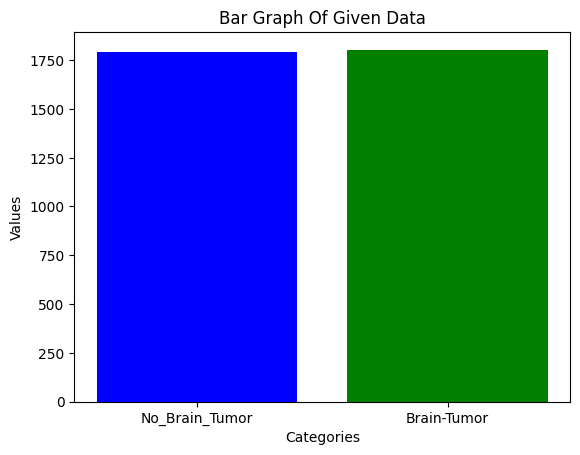

In [8]:
brain_tumor_no_img=os.listdir(os.path.join(train_dir,"NO"))
brain_tumor_yes_img=os.listdir(os.path.join(train_dir,"YES"))

values= [len(brain_tumor_no_img),len(brain_tumor_yes_img)]
labels=['No_Brain_Tumor','Brain-Tumor']

plt.bar(labels,values,color=['blue','green'])
plt.xlabel("Categories")
plt.ylabel("Values")
plt.title("Bar Graph Of Given Data")

plt.show()

In [9]:
# Initialize the ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rescale = 1./255,   #normalize the pixel values[0,1]
    validation_split=0.2,  #set validation split
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'   #how to fill in new pixels after transformation

)

#Load training and validation datasets using flow from directory
traindata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle='True'

)
#Load training and validation datasets using flow from directory
valdata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle='True'

)


Found 3598 images belonging to 2 classes.
Found 3598 images belonging to 2 classes.


In [10]:
print(traindata.class_indices)

{'NO': 0, 'YES': 1}


(32, 2)
(32, 224, 224, 1)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


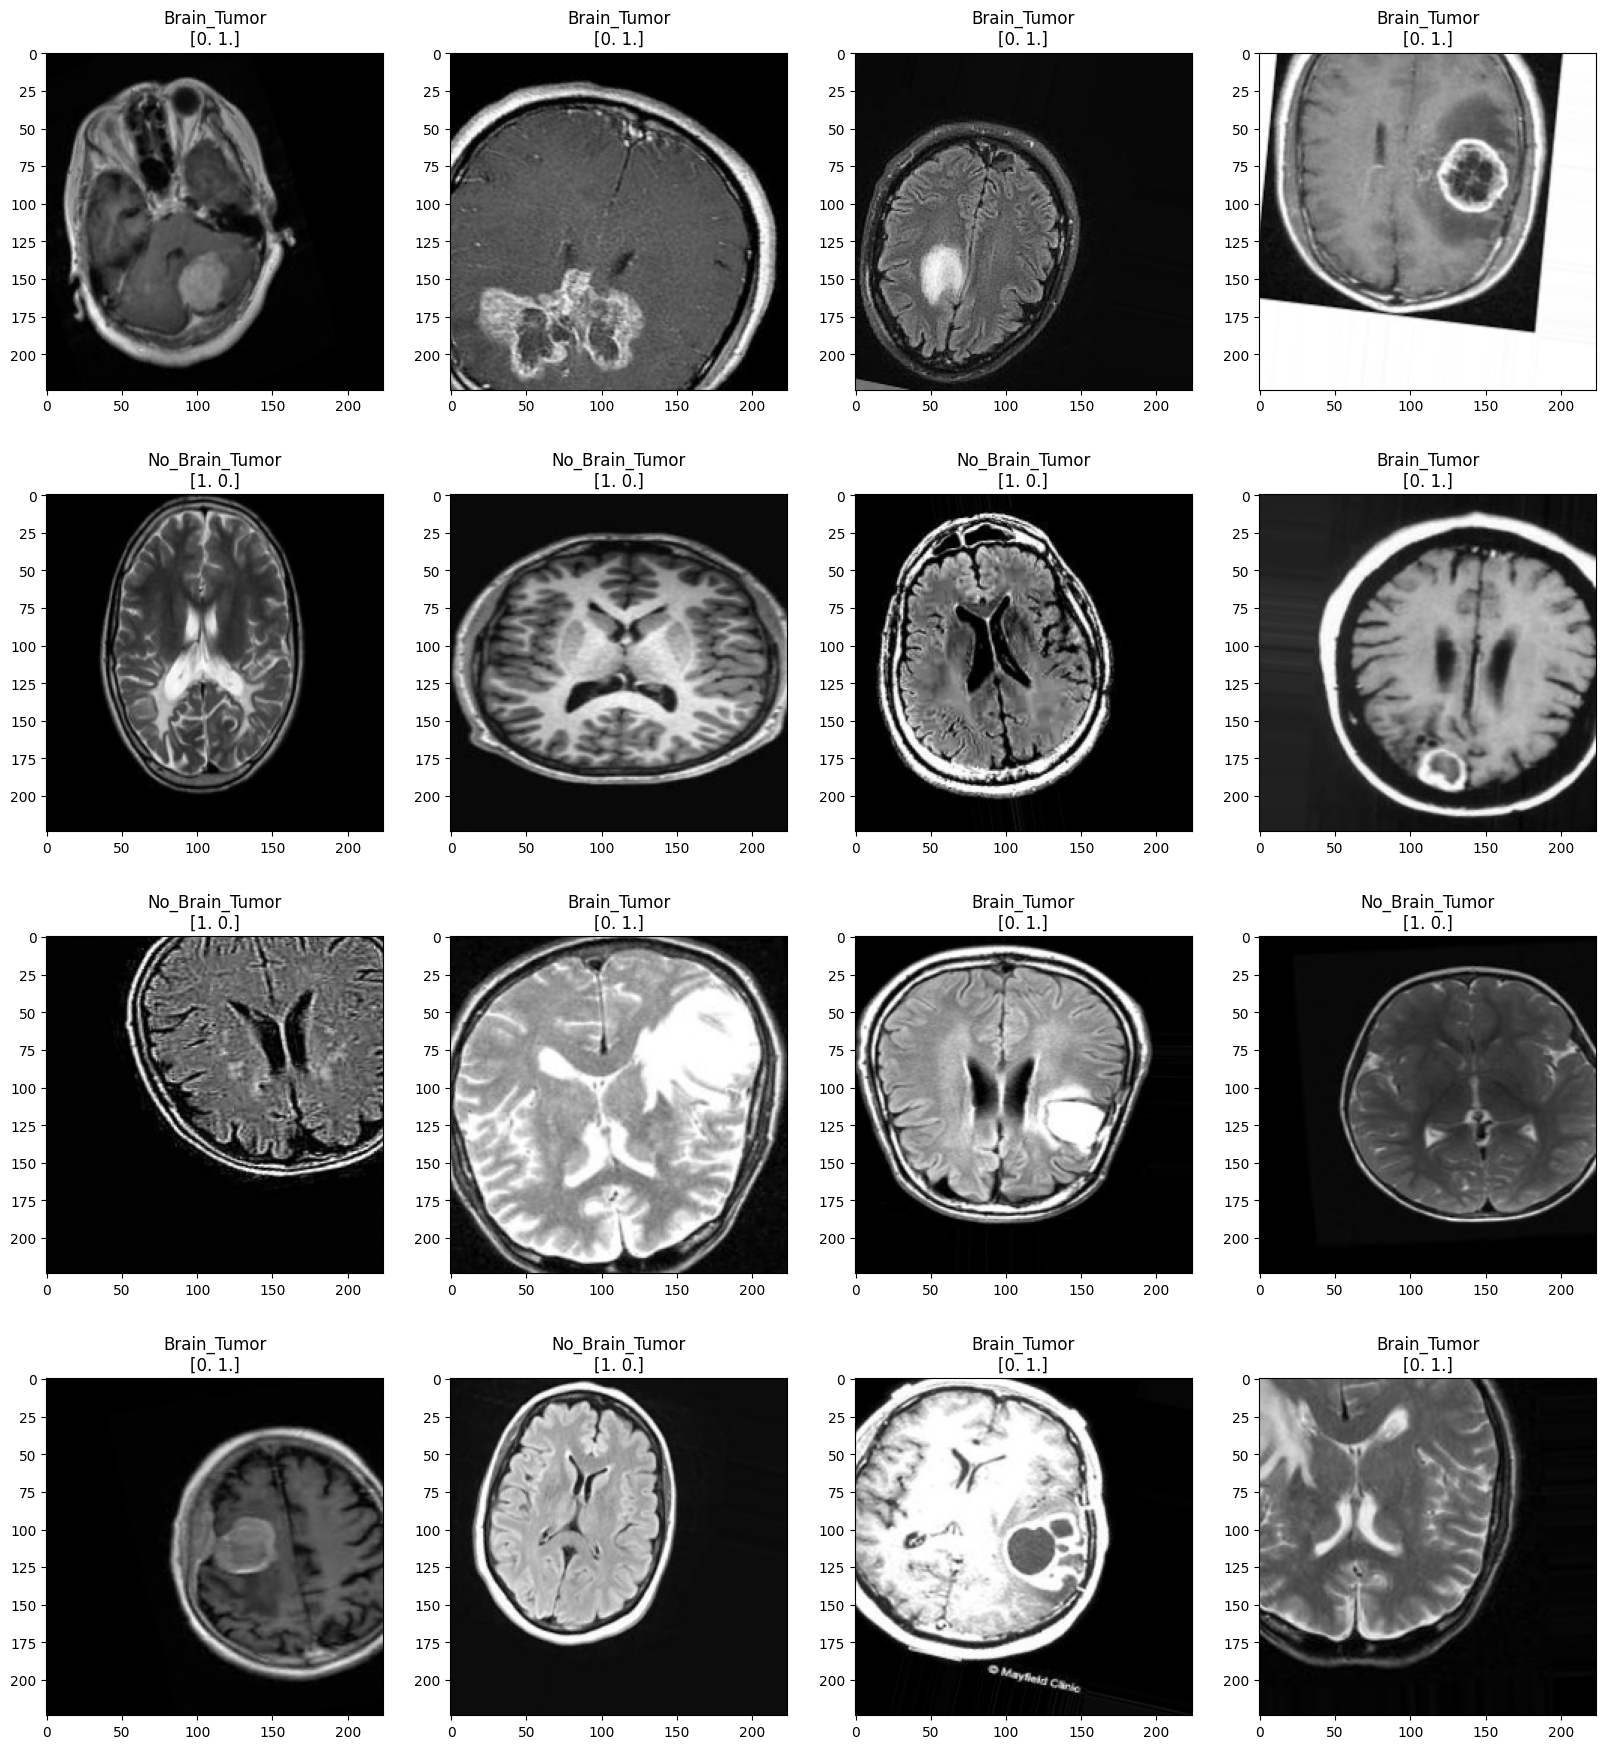

In [11]:
class_name = {0:'No_Brain_Tumor',1:'Brain_Tumor'}

trainiter= iter(traindata)
images,labels=next(trainiter)

print(labels.shape)
print(images.shape)
print(type(labels))
print(type(images))

fig,axes= plt.subplots(4,4,figsize=(20,22))
axes= axes.ravel()

for i in range(16):
  axes[i].imshow(images[i],cmap='gray')
  index=np.argmax(labels[i])
  axes[i].set_title(f'{class_name[index]}\n{labels[i]}')

plt.show()


In [12]:
input_size = (224,224,1)

model=Sequential()

model.add(Conv2D(16, (3,3), activation='relu', input_shape=input_size))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, (3,3), activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(512, (3,3), activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(2, activation='softmax'))

opt = Adam(learning_rate=0.0008)
model.compile(loss='categorical_crossentropy',optimizer=opt,metrics=['accuracy'])
model.summary()







/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,099,906 (53.79 MB)

 Trainable params: 14,095,586 (53.77 MB)

 Non-trainable params: 4,320 (16.88 KB)

In [13]:
modelcheckpoint= ModelCheckpoint('model.keras',
                                 monitor = 'val_accuracy',
                                 save_best_only = True,
                                 verbose = 1)

#Laerning Rate Scheduler (Cosine Annealing)
def scheduler(epoch, lr):
  return 0.001 * (0.5 ** (epochs // 10))

lr_scheduler = LearningRateScheduler(scheduler)


In [14]:
# Train the model

epochs = 30
history = model.fit(traindata,
                    callbacks = [modelcheckpoint,lr_scheduler],
                    validation_data = valdata,
                    epochs = epochs)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6659 - loss: 0.7625
Epoch 1: val_accuracy improved from -inf to 0.50334, saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 467s 4s/step - accuracy: 0.6662 - loss: 0.7614 - val_accuracy: 0.5033 - val_loss: 0.6903 - learning_rate: 1.2500e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7835 - loss: 0.4810
Epoch 2: val_accuracy did not improve from 0.50334
113/113 ━━━━━━━━━━━━━━━━━━━━ 498s 4s/step - accuracy: 0.7836 - loss: 0.4809 - val_accuracy: 0.4986 - val_loss: 0.8296 - learning_rate: 1.2500e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8113 - loss: 0.4235
Epoch 3: val_accuracy improved from 0.50334 to 0.57699, saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 454s 4s/step - accuracy: 0.8113 - loss: 0.4235 - val_accuracy: 0.5770 - val_loss: 0.7875 - learning_rate: 1.2500e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8275 - loss: 0.3850
Epoch 

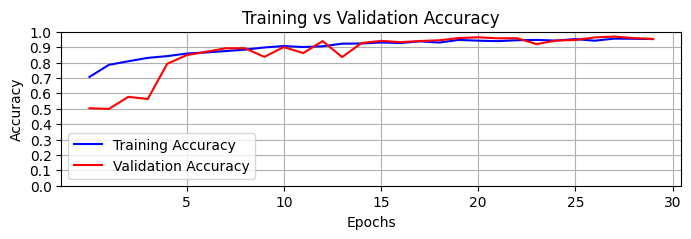

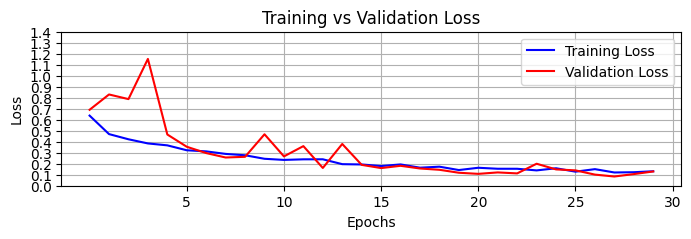

In [15]:
plt.figure(figsize=(8, 2))
plt.plot(history.history['accuracy'], label="Training Accuracy", color='b')
plt.plot(history.history['val_accuracy'], label="Validation Accuracy", color='r')
plt.xticks(np.arange(5, epochs + 1, 5))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 2))
plt.plot(history.history['loss'], label="Training Loss", color='b')
plt.plot(history.history['val_loss'], label="Validation Loss", color='r')
plt.xticks(np.arange(5, epochs + 1, 5))
plt.yticks(np.arange(0, 1.5, 0.1))
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(loc='best')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
[0.9662486  0.03375143]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[0.9636258  0.03637419]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[0.2887258  0.71127415]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[0.00709103 0.99290895]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[0.9987999  0.00120008]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[0.5373456 0.4626545]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[0.07068269 0.9293173 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[0.00600553 0.99399453]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[0.24223512 0.7577649 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[0.00343845 0.9965616 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[0.12036695 0.879633  ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[0.95804256 0.04195747]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[9.535186e-04 9.990465e-01]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[0.9435343  0.05646572]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[0.99794966 0.0020503 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[0.03910011 0.9608999 ]


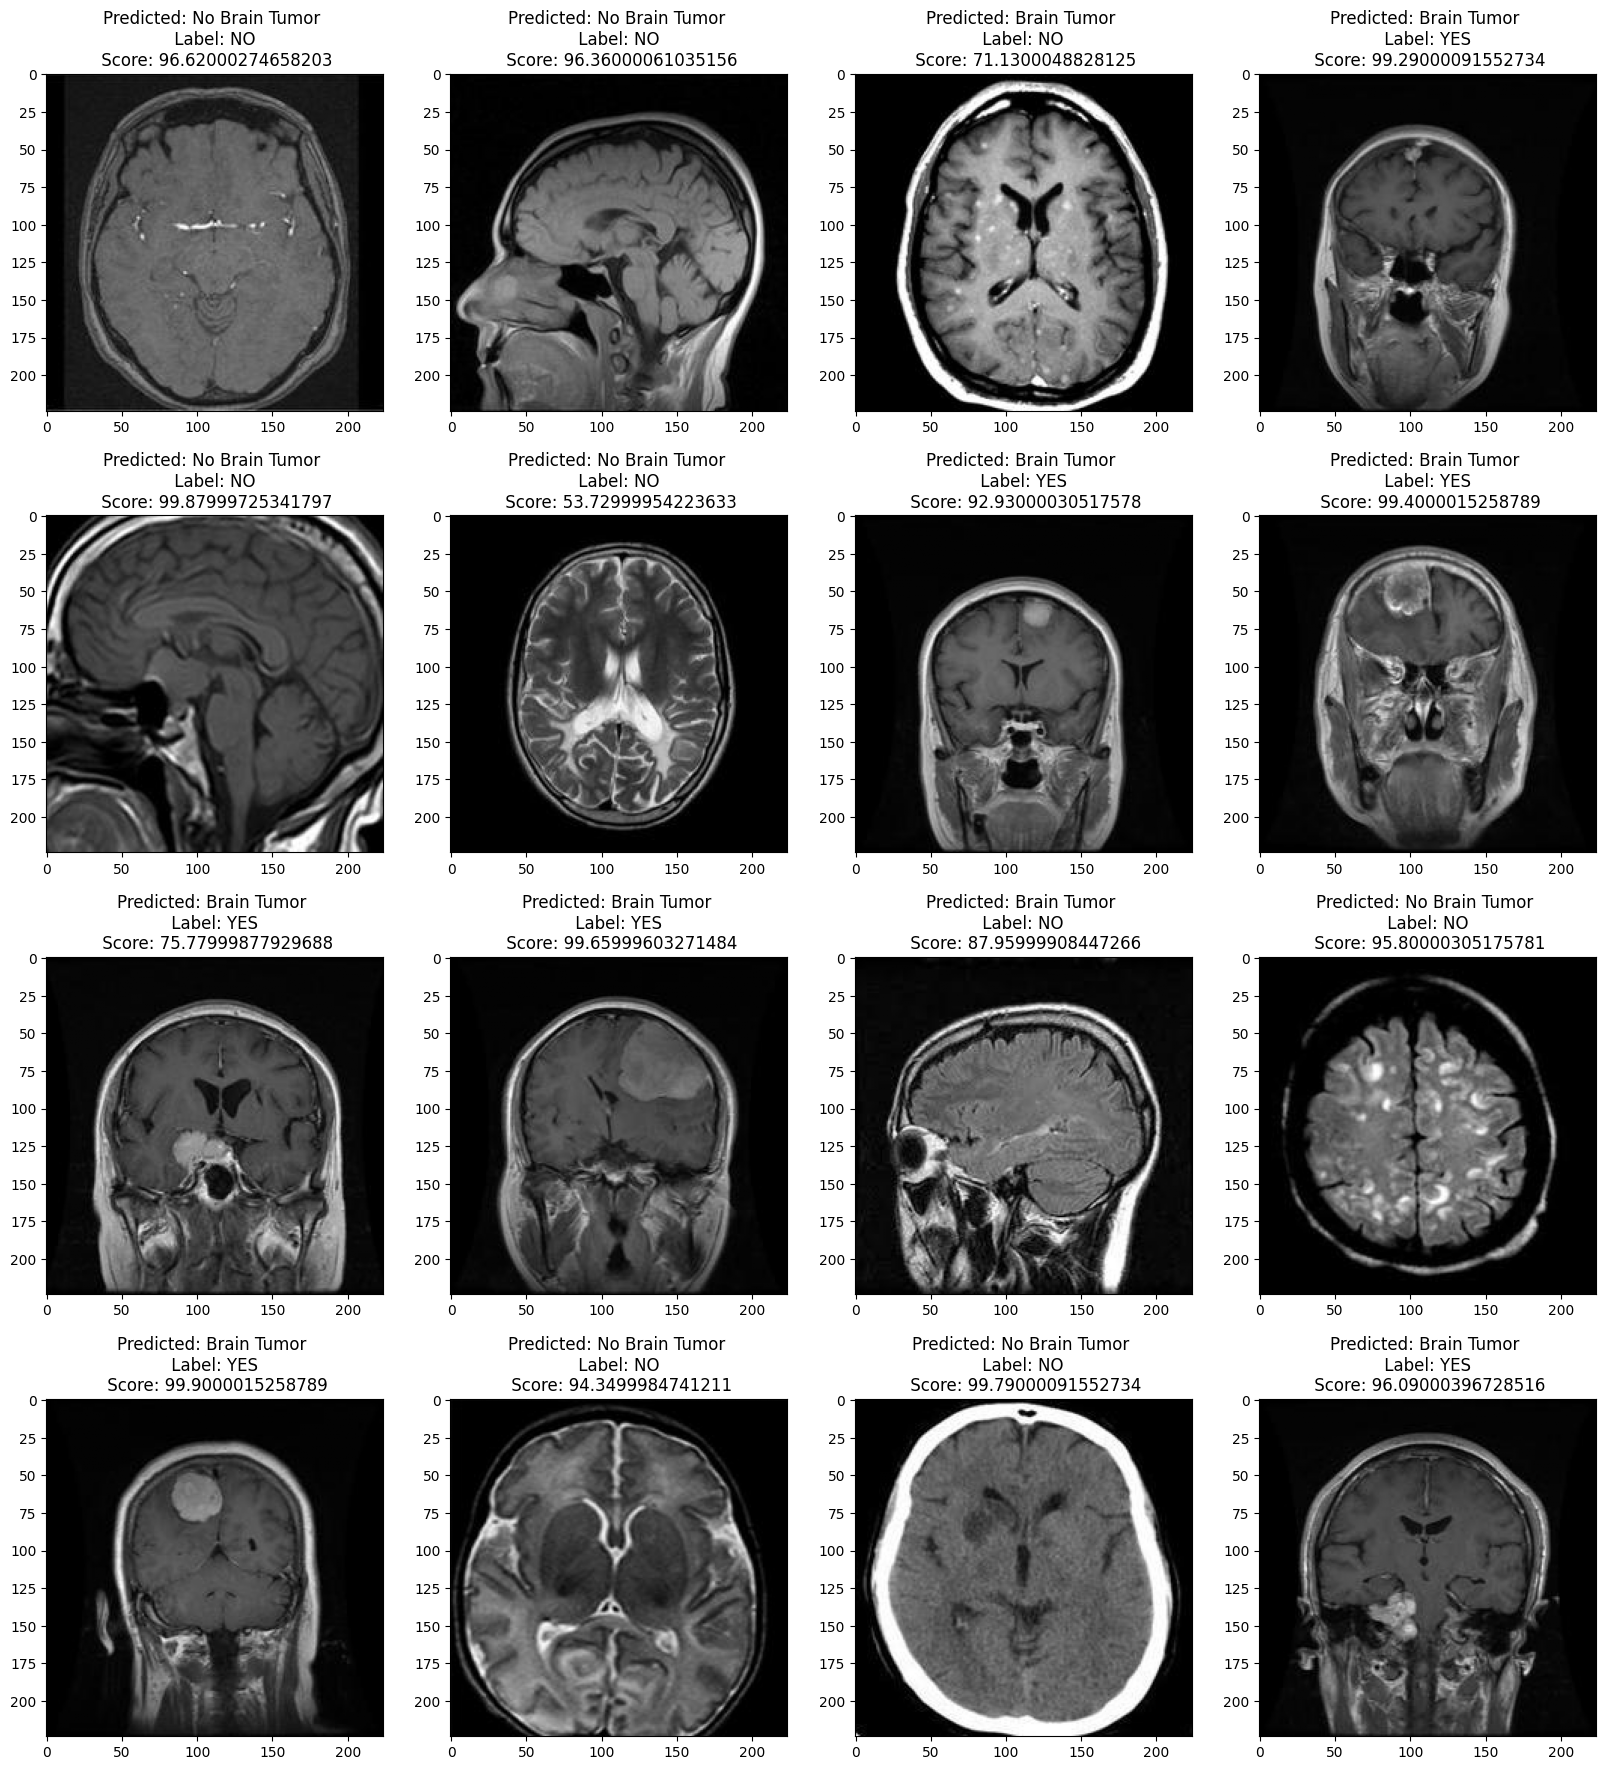

In [16]:
from PIL import Image, ImageOps
import os
import random

model = keras.models.load_model("model.keras")

fig, axes = plt.subplots(4,4, figsize=(20,22))
axes = axes.ravel()

class_name = {0:'No Brain Tumor', 1:'Brain Tumor'}

test_dir = 'Brain_Tumor_Datasets/test'
test_dir_folders = os.listdir(test_dir)


for i in range(16):
  test_dir_folder = random.choice(test_dir_folders)
  test_dir_files = os.listdir(os.path.join(test_dir,test_dir_folder))
  img_path = os.path.join(test_dir,test_dir_folder,random.choice(test_dir_files))

  img = Image.open(img_path)
  img = ImageOps.grayscale(img)
  img_pred = np.array(img)
  img_pred = np.expand_dims(img_pred, axis=0)
  img_pred = img_pred / 255.0

  pred = model.predict(img_pred)[0]

  pred_index = np.argmax(pred, axis=-1)
  score = np.round(pred[pred_index], 4) * 100
  actual_index = np.argmax(labels[i], axis=-1)
  print(pred)

  axes[i].imshow(img,cmap='gray')
  axes[i].set_title(f'Predicted: {class_name[pred_index]} \n Label: {test_dir_folder} \n Score: {score}')

plt.show()